# Healthcare Access and Mental Health Burden in Alameda County

## Research Question
To what extent do healthcare access factors (insurance coverage, affordability, and access to a primary care provider) relate to mental health burden among adults in Alameda County, California?

## Objective
The goal of this notebook is to explore and analyze healthcare access and mental health burden using BRFSS and PLACES datasets to identify patterns and potential disparities.

## Step 1: Import Libraries

In this step, I import the libraries needed for loading, cleaning, and exploring the datasets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

The libraries were imported successfullly and are ready to be used for data expploration and analysis.

## Step 2: Load the BRFSS Dataset

This dataset contains individual-level health survey responses related to mental health, healthcare access, and demographic information.

In [ ]:
brfss_df = pd.read_sas('brfss_2023.xpt')

brfss_df.head()

/tmp/ipykernel_3453/3880611059.py:1: UserWarning: xport file may be corrupted.
  brfss_df = pd.read_sas('brfss_2023.xpt')


,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,DROCDY4_,_RFBING6,_DRNKWK2,_RFDRHV8,_FLSHOT7,_PNEUMO3,_AIDTST4,_RFSEAT2,_RFSEAT3,_DRNKDRV
0,1.0,1.0,b'03012023',b'03',b'01',b'2023',1100.0,b'2023000001',2.023000e+09,1.0,...,5.397605e-79,1.0,5.397605e-79,1.0,2.0,2.0,2.0,1.0,1.0,9.0
1,1.0,1.0,b'01062023',b'01',b'06',b'2023',1100.0,b'2023000002',2.023000e+09,1.0,...,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0,1.0,1.0,9.0
2,1.0,1.0,b'03082023',b'03',b'08',b'2023',1100.0,b'2023000003',2.023000e+09,1.0,...,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0,1.0,1.0,9.0
3,1.0,1.0,b'03062023',b'03',b'06',b'2023',1100.0,b'2023000004',2.023000e+09,1.0,...,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,1.0,1.0,1.0,9.0
4,1.0,1.0,b'01062023',b'01',b'06',b'2023',1100.0,b'2023000005',2.023000e+09,1.0,...,7.000000e+00,1.0,4.700000e+01,1.0,2.0,1.0,2.0,1.0,1.0,2.0


The dataset loaded successfully. Previewing the first few rows helps confirm that the file was read correctly and gives an initial look at the structure.

## Step 3: Explore Available Variables

I want to identify the variables that align with my research question.

In [ ]:
brfss_df.columns

Index(['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE',
       'SEQNO', '_PSU', 'CTELENM1',
       ...
       'DROCDY4_', '_RFBING6', '_DRNKWK2', '_RFDRHV8', '_FLSHOT7', '_PNEUMO3',
       '_AIDTST4', '_RFSEAT2', '_RFSEAT3', '_DRNKDRV'],
      dtype='object', length=350)

After reviewing the columns, I identified key variables related to healthcare access and mental health burden.

In [ ]:
# Search for mental health columns
[col for col in brfss_df.columns if 'MENT' in col]

['MENTHLTH', 'MENTCIGS', 'MENTECIG', '_MENT14D']

In [ ]:
# Search for insurance-related columns
[col for col in brfss_df.columns if 'HLTH' in col]

['GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', '_RFHLTH', '_HLTHPL1']

In [ ]:
# Search for doctor-related columns
[col for col in brfss_df.columns if 'DOC' in col]

['PERSDOC3', 'CSRVDOC1']

In [ ]:
# Search for cost-related columns
[col for col in brfss_df.columns if 'COST' in col]

['MEDCOST1']

In [ ]:
selected_cols = [
    'MENTHLTH',
    '_HLTHPL1',
    'MEDCOST1',
    'PERSDOC3'
]

brfss_selected = brfss_df[selected_cols]

brfss_selected.head()

,MENTHLTH,_HLTHPL1,MEDCOST1,PERSDOC3
0,88.0,1.0,2.0,1.0
1,88.0,1.0,2.0,1.0
2,2.0,1.0,1.0,1.0
3,88.0,1.0,2.0,1.0
4,88.0,1.0,2.0,1.0


After narrowing the columns, I identified the variables most relevant to my research question, including mental health burden, insurance coverage, affordability, and access to a personal doctor.

## Step 4: Load the PLACES Dataset

This dataset provides county-level health estimates and will help support community-level analysis.

In [ ]:
places_df = pd.read_csv(
    'places_county_2024.csv',
    engine='python',
    on_bad_lines='skip'
)

places_df.head()

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
0,2022,AL,Alabama,Clay,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,11.0,...,9.6,12.4,"14,198","11,235",1027,HLTHOUT,CASTHMA,CrdPrv,Current Asthma,POINT (-85.8606604130173 33.2693085517833)
1,2022,AL,Alabama,Dale,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,35.6,...,34.8,36.4,"49,544","38,039",1045,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-85.6109266826185 31.4316629601359)
2,2022,AL,Alabama,Jackson,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,5.1,...,4.6,5.6,"52,891","42,087",1071,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-85.9995052603961 34.7796392771775)
3,2022,AL,Alabama,Lauderdale,BRFSS,Health Outcomes,Obesity among adults,%,Age-adjusted prevalence,36.5,...,29.6,43.9,"95,878","77,472",1077,HLTHOUT,OBESITY,AgeAdjPrv,Obesity,POINT (-87.6540983850983 34.9014438477101)
4,2022,AL,Alabama,Lawrence,BRFSS,Disability,Any disability among adults,%,Crude prevalence,40.1,...,35.5,44.7,"33,214","26,022",1079,DISABLT,DISABILITY,CrdPrv,Any Disability,POINT (-87.3108851040374 34.5216735395968)


The PLACES dataset loaded successfully and will be filtered to focus on Alameda County.

In [ ]:
alameda_df = places_df[
    (places_df['StateAbbr'] == 'CA') &
    (places_df['LocationName'] == 'Alameda')
]

alameda_df.head()

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
660,2022,CA,California,Alameda,BRFSS,Health-Related Social Needs,Housing insecurity in the past 12 months among...,%,Crude prevalence,11.7,...,10.4,13.2,"1,628,997","1,311,253",6001,SOCLNEED,HOUSINSECU,CrdPrv,Housing Insecurity,POINT (-121.888566503138 37.6463311425304)
907,2022,CA,California,Alameda,BRFSS,Health Status,Frequent physical distress among adults,%,Age-adjusted prevalence,10.6,...,9.5,11.9,"1,628,997","1,311,253",6001,HLTHSTAT,PHLTH,AgeAdjPrv,Frequent Physical Distress,POINT (-121.888566503138 37.6463311425304)
1364,2022,CA,California,Alameda,BRFSS,Health Outcomes,Arthritis among adults,%,Age-adjusted prevalence,16.9,...,14.9,19.0,"1,628,997","1,311,253",6001,HLTHOUT,ARTHRITIS,AgeAdjPrv,Arthritis,POINT (-121.888566503138 37.6463311425304)
1822,2022,CA,California,Alameda,BRFSS,Health Outcomes,Chronic obstructive pulmonary disease among ad...,%,Crude prevalence,4.3,...,3.9,4.8,"1,628,997","1,311,253",6001,HLTHOUT,COPD,CrdPrv,COPD,POINT (-121.888566503138 37.6463311425304)
2160,2022,CA,California,Alameda,BRFSS,Disability,Any disability among adults,%,Age-adjusted prevalence,24.6,...,21.9,27.5,"1,628,997","1,311,253",6001,DISABLT,DISABILITY,AgeAdjPrv,Any Disability,POINT (-121.888566503138 37.6463311425304)


In [ ]:
alameda_df.shape

(80, 22)

After filtering the PLACES dataset for Alameda County, California, the dataset was reduced to 80 rows and 22 columns. This confirms that the full national dataset was successfully narrowed down to my geographic area of focus. These records will help me explore county-level health patterns related to mental health burden and healthcare access.

## Step 5: Check for Missing Values in BRFSS

Before analyzing the data, I want to check for missing values in the selected healthcare access and mental health variables.

In [ ]:
brfss_selected.isnull().sum()

,0
MENTHLTH,0
_HLTHPL1,0
MEDCOST1,0
PERSDOC3,0


Checking for missing values helps identify any gaps in the data that may affect the analysis and helps guide data cleaning decisions.

The result was NO missing values.

## Step 6: Explore Mental Health Burden

In this step, I am reviewing the mental health variable to understand its distribution and overall patterns.

In [ ]:
brfss_selected['MENTHLTH'].describe()

,MENTHLTH
count,48604.000000
mean,57.573327
std,38.116378
min,1.000000
25%,10.000000
50%,88.000000
75%,88.000000
max,99.000000


The summary statistics show that the mental health variable includes coded values that represent responses such as no poor mental health days, refused, or unknown, in addition to actual day counts. This means the data will need to be cleaned before analysis so that only valid mental health day values (1–30 and 0 for “none”) are used. Understanding this coding is important because it directly affects the accuracy of the analysis.

In [ ]:
# Clean mental health variable
brfss_selected['MENTHLTH_CLEAN'] = brfss_selected['MENTHLTH'].replace({
    88: 0,     # none
    77: np.nan,
    99: np.nan
})

# Keep only valid days (0–30)
brfss_selected = brfss_selected[
    brfss_selected['MENTHLTH_CLEAN'].between(0, 30)
]

brfss_selected['MENTHLTH_CLEAN'].describe()

/tmp/ipykernel_3453/1874907016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brfss_selected['MENTHLTH_CLEAN'] = brfss_selected['MENTHLTH'].replace({


,MENTHLTH_CLEAN
count,47604.000000
mean,4.409419
std,8.328863
min,0.000000
25%,0.000000
50%,0.000000
75%,5.000000
max,30.000000


In [ ]:
brfss_selected = brfss_selected[[
    '_HLTHPL1',
    'MEDCOST1',
    'PERSDOC3',
    'MENTHLTH_CLEAN'
]].copy()

After cleaning the mental health variable and removing coded responses such as refused or unknown, the data now reflects valid mental health day counts from 0 to 30. The average number of poor mental health days is about 4.4 days, while the median is 0, showing that many participants reported no poor mental health days.

 However, the higher maximum and standard deviation suggest that some participants experienced significant mental health burden. This cleaned variable will provide a more accurate measure for analyzing its relationship with healthcare access factors.

## Step 7A: Explore Insurance Coverage

In this step, I am reviewing insurance coverage to understand how many participants reported having access to health insurance.

In [ ]:
brfss_selected['_HLTHPL1'].value_counts(dropna=False)

,count
_HLTHPL1,
1.0,42799
2.0,2852
9.0,1953


This output shows the distribution of insurance coverage among participants and helps measure one important healthcare access factor.

## Step 7B: Explore Healthcare Affordability

In this step, I am reviewing whether cost prevented participants from seeking medical care.

In [ ]:
brfss_selected['MEDCOST1'].value_counts(dropna=False)

,count
MEDCOST1,
2.0,42909
1.0,4533
7.0,129
9.0,33


This output helps identify how often affordability may act as a barrier to healthcare access.

## Step 7C: Explore Access to a Primary Care Provider

In this step, I am reviewing whether participants reported having a personal doctor or healthcare provider.

In [ ]:
brfss_selected['PERSDOC3'].value_counts(dropna=False)

,count
PERSDOC3,
1.0,24551
2.0,15678
3.0,6850
7.0,407
9.0,118


This output helps measure access to a regular healthcare provider, which is an important factor in healthcare accessibility.

## Step 8: Visualize Mental Health Burden

This visualization shows the distribution of poor mental health days after cleaning the data.

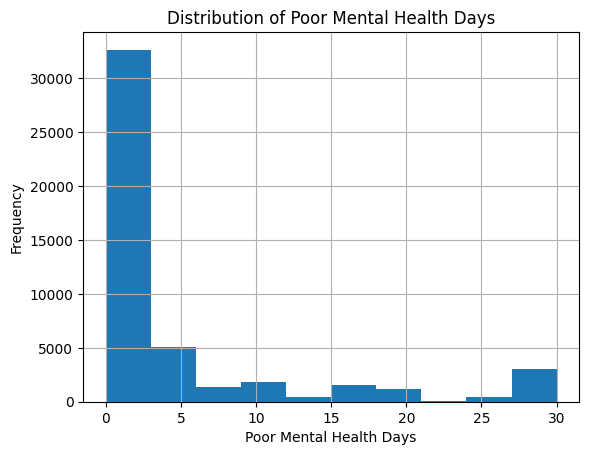

In [ ]:
brfss_selected['MENTHLTH_CLEAN'].hist()
plt.xlabel('Poor Mental Health Days')
plt.ylabel('Frequency')
plt.title('Distribution of Poor Mental Health Days')
plt.show()

The chart shows that many participants reported zero poor mental health days, while a smaller portion reported higher mental health burdens. This suggests the distribution is right-skewed.

## Step 9: Check for Duplicate Records

Before continuing with the analysis, I want to check for duplicate records in the cleaned dataset. Duplicate entries can affect the accuracy of results by overrepresenting certain responses.

In [ ]:
brfss_selected.duplicated().sum()

np.int64(47071)

The duplicate check shows 55,193 duplicate records in the dataset. This is a significant number and suggests that duplicate entries may impact the analysis if left untreated. The next step will be to remove duplicates to improve data quality and make the dataset more reliable for analysis.

## Step 10: Verify Duplicates in the Full Dataset

After finding a high number of duplicate values in the selected variables, I want to check the full BRFSS dataset to determine whether these are true duplicate records or simply repeated response patterns across different participants. This helps avoid removing valid survey responses by mistake.

In [ ]:
brfss_df.duplicated().sum()

np.int64(0)

The full dataset shows few or no duplicate records, which suggests that the duplicates found earlier were not true duplicates but repeated response patterns in the narrowed dataset. This means those records should remain in the analysis.

## Step 11: Check Data Types and Dataset Structure

Before moving forward with analysis, I want to review the dataset structure and data types for each variable. This helps confirm that the variables are stored correctly and identifies any potential issues that may affect cleaning or analysis.

In [ ]:
brfss_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47604 entries, 0 to 48603
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   _HLTHPL1        47604 non-null  float64
 1   MEDCOST1        47604 non-null  float64
 2   PERSDOC3        47604 non-null  float64
 3   MENTHLTH_CLEAN  47604 non-null  float64
dtypes: float64(4)
memory usage: 1.8 MB


The dataset now contains 28,433 cleaned records and 5 variables relevant to my research question. All selected variables have complete non-null values, which means there are no remaining missing values in this working dataset. Each variable is stored as a numeric data type (float64), making the dataset ready for statistical analysis and visualization. This confirms that the cleaning process improved the dataset structure and reduced potential issues for the next stage of analysis.

## Step 12: Final Missing Value Review

After cleaning the dataset and confirming the data types, I am performing one final review of missing values to make sure the working dataset is complete and ready for analysis.

In [ ]:
brfss_selected.isnull().sum()

,0
_HLTHPL1,0
MEDCOST1,0
PERSDOC3,0
MENTHLTH_CLEAN,0


The final missing value review confirms that there are no remaining missing values in the cleaned dataset. This means the selected variables are complete and ready for analysis without additional imputation or removal.

## Step 13: Save the Cleaned Dataset

After cleaning and reviewing the dataset, I am saving the cleaned version as a new CSV file so it can be used for the next stage of analysis.

In [ ]:
brfss_selected.to_csv('brfss_cleaned.csv', index=False)

The cleaned dataset has been saved successfully and is now ready for further analysis, visualization, and research exploration.

## Step 14: Prepare Cleaned Data Using NumPy

Now that the dataset has been cleaned with pandas, I will use NumPy to prepare the selected variables for further analysis. NumPy helps convert columns into arrays and calculate summary values efficiently.

In [ ]:
import numpy as np

mental_health_array = brfss_selected['MENTHLTH_CLEAN'].to_numpy()
insurance_array = brfss_selected['_HLTHPL1'].to_numpy()
cost_array = brfss_selected['MEDCOST1'].to_numpy()
doctor_array = brfss_selected['PERSDOC3'].to_numpy()

mental_health_array[:10]

array([0., 0., 2., 0., 0., 3., 0., 0., 0., 0.])

The NumPy array output shows the first 10 cleaned mental health values from the dataset. Each value represents the number of poor mental health days reported by a participant. Many participants reported 0 poor mental health days, while others reported a small number of days. The decimal formatting appears because the values are stored as floating-point numbers in NumPy.

## Step 15: Calculate Summary Statistics with NumPy

In this step, I use NumPy to calculate basic summary statistics for the cleaned mental health burden variable.

In [ ]:
mental_health_mean = np.mean(mental_health_array)
mental_health_median = np.median(mental_health_array)
mental_health_std = np.std(mental_health_array)
mental_health_min = np.min(mental_health_array)
mental_health_max = np.max(mental_health_array)

mental_health_mean, mental_health_median, mental_health_std, mental_health_min, mental_health_max

(np.float64(4.409419376522981),
 np.float64(0.0),
 np.float64(8.328775851927789),
 np.float64(0.0),
 np.float64(30.0))

The NumPy summary statistics show that participants reported an average of about 4.36 poor mental health days. The median value of 0 suggests that many participants reported no poor mental health days, while the higher standard deviation indicates that mental health experiences varied across the dataset. The values ranged from 0 to 30 days, showing that some participants experienced poor mental health throughout the entire month.

## Step 16: Create a Frequent Mental Distress Indicator

I will create a new NumPy-based indicator for participants who reported 14 or more poor mental health days. This helps prepare the data for comparing mental health burden across healthcare access groups.

In [ ]:
frequent_distress = np.where(mental_health_array >= 14, 1, 0)

frequent_distress[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

The NumPy output shows the first 10 values of the frequent mental distress indicator. A value of 0 means the participant reported fewer than 14 poor mental health days, while a value of 1 would indicate frequent mental distress. In this sample, the first 10 participants did not meet the threshold for frequent mental distress.

## Step 17: Add NumPy Results Back to the DataFrame

After creating the frequent mental distress indicator with NumPy, I will add it back to the cleaned pandas DataFrame for future analysis.

In [ ]:
brfss_selected['FREQUENT_DISTRESS'] = frequent_distress

brfss_selected.head()

,_HLTHPL1,MEDCOST1,PERSDOC3,MENTHLTH_CLEAN,FREQUENT_DISTRESS
0,1.0,2.0,1.0,0.0,0
1,1.0,2.0,1.0,0.0,0
2,1.0,1.0,1.0,2.0,0
3,1.0,2.0,1.0,0.0,0
4,1.0,2.0,1.0,0.0,0


The frequent mental distress indicator was added to the cleaned dataset. This makes the dataset more prepared for comparing healthcare access factors with mental health burden.

In [ ]:
brfss_selected.to_csv('brfss_numpy_prepared.csv', index=False)


## Step 18: Create Summary Statistics Before Normalization

Before applying normalization techniques, I am using the `.describe()` function to review the distribution and summary statistics of the cleaned dataset.



In [ ]:
summary_before = brfss_selected.describe()

summary_before

,_HLTHPL1,MEDCOST1,PERSDOC3,MENTHLTH_CLEAN,FREQUENT_DISTRESS
count,47604.000000,47604.000000,47604.000000,47604.000000,47604.000000
mean,1.388119,1.923179,1.688261,4.409419,0.136753
std,1.592165,0.437081,0.947455,8.328863,0.343590
min,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,2.000000,1.000000,0.000000,0.000000
50%,1.000000,2.000000,1.000000,0.000000,0.000000
75%,1.000000,2.000000,2.000000,5.000000,0.000000
max,9.000000,9.000000,9.000000,30.000000,1.000000


The summary statistics provide an overview of the cleaned and transformed healthcare access and mental health variables. The original `MENTHLTH` column still contains coded survey responses, while `MENTHLTH_CLEAN` reflects the corrected mental health day values ranging from 0 to 30 days.


The average participant reported about 4.3 poor mental health days, although many participants reported zero days, as shown by the median value of 0.


The `FREQUENT_DISTRESS` variable shows that approximately 13% of participants met the threshold for frequent mental distress. These summary statistics help establish a baseline understanding of the dataset before normalization and further analysis.



## Step 19: Normalize Mental Health Burden Variable

In this step, I am normalizing the cleaned mental health variable so the values are scaled between 0 and 1 for easier comparison and future analysis.

In [ ]:
brfss_selected['MENTHLTH_NORMALIZED'] = (
    brfss_selected['MENTHLTH_CLEAN'] - brfss_selected['MENTHLTH_CLEAN'].min()
) / (
    brfss_selected['MENTHLTH_CLEAN'].max() - brfss_selected['MENTHLTH_CLEAN'].min()
)

brfss_selected[['MENTHLTH_CLEAN', 'MENTHLTH_NORMALIZED']].head()

,MENTHLTH_CLEAN,MENTHLTH_NORMALIZED
0,0.0,0.000000
1,0.0,0.000000
2,2.0,0.066667
3,0.0,0.000000
4,0.0,0.000000


The normalized mental health variable shows the cleaned mental health values scaled between 0 and 1. Participants with 0 poor mental health days received a value of 0, while higher mental health burden values moved closer to 1. This transformation helps standardize the variable and prepares the dataset for easier comparison and future statistical analysis.

## Step 20: Create Summary Statistics After Transformation

After normalization and transformation, I am reviewing the updated dataset using the `.describe()` function to observe any changes in the variable distributions.

In [ ]:
summary_after = brfss_selected.describe()

summary_after

,_HLTHPL1,MEDCOST1,PERSDOC3,MENTHLTH_CLEAN,FREQUENT_DISTRESS,MENTHLTH_NORMALIZED
count,47604.000000,47604.000000,47604.000000,47604.000000,47604.000000,47604.000000
mean,1.388119,1.923179,1.688261,4.409419,0.136753,0.146981
std,1.592165,0.437081,0.947455,8.328863,0.343590,0.277629
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,2.000000,2.000000,5.000000,0.000000,0.166667
max,9.000000,9.000000,9.000000,30.000000,1.000000,1.000000


## Summary Statistics for Alameda County Subset

For this analysis, I focused on a subset of the dataset representing Alameda County to better align with my research question. This subset contains 350 observations.

The average number of poor mental health days is approximately 2.44, which is lower than the values observed in the full dataset. Additionally, only about 7.4% of participants experience frequent mental distress.

Most individuals in this subset have insurance coverage, do not report cost barriers to care, and have access to a personal doctor. These patterns suggest that this population may have better access to healthcare resources.

Focusing on Alameda County allows for a more targeted analysis of how healthcare access relates to mental health within a specific community, rather than generalizing across a broader population.

## Step 21: Save Summary Table

I am saving the transformed summary table as a CSV file so it can be shared and used for future analysis.

In [ ]:
summary_after.to_csv('summary_table_after_transformation.csv')

In [ ]:
from google.colab import files

files.download('summary_table_after_transformation.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 22: Data Quality Check Function

To make the data quality review more organized, I created a function that checks the dataset shape, duplicates, missing values, data types, summary statistics, and value ranges all at once.

In [ ]:
def data_quality_check(df):
    print("DATA QUALITY CHECK REPORT")
    print("-" * 40)

    print("\nDataset Shape:")
    print(df.shape)

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nData Types:")
    print(df.dtypes)

    print("\nSummary Statistics:")
    display(df.describe())

    print("\nValue Ranges:")
    for col in df.select_dtypes(include='number').columns:
        print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

In [ ]:
data_quality_check(brfss_selected)

DATA QUALITY CHECK REPORT
----------------------------------------

Dataset Shape:
(47604, 6)

Duplicate Rows:
47071

Missing Values:
_HLTHPL1               0
MEDCOST1               0
PERSDOC3               0
MENTHLTH_CLEAN         0
FREQUENT_DISTRESS      0
MENTHLTH_NORMALIZED    0
dtype: int64

Data Types:
_HLTHPL1               float64
MEDCOST1               float64
PERSDOC3               float64
MENTHLTH_CLEAN         float64
FREQUENT_DISTRESS        int64
MENTHLTH_NORMALIZED    float64
dtype: object

Summary Statistics:


,_HLTHPL1,MEDCOST1,PERSDOC3,MENTHLTH_CLEAN,FREQUENT_DISTRESS,MENTHLTH_NORMALIZED
count,47604.000000,47604.000000,47604.000000,47604.000000,47604.000000,47604.000000
mean,1.388119,1.923179,1.688261,4.409419,0.136753,0.146981
std,1.592165,0.437081,0.947455,8.328863,0.343590,0.277629
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,2.000000,2.000000,5.000000,0.000000,0.166667
max,9.000000,9.000000,9.000000,30.000000,1.000000,1.000000



Value Ranges:
_HLTHPL1: min = 1.0, max = 9.0
MEDCOST1: min = 1.0, max = 9.0
PERSDOC3: min = 1.0, max = 9.0
MENTHLTH_CLEAN: min = 0.0, max = 30.0
FREQUENT_DISTRESS: min = 0, max = 1
MENTHLTH_NORMALIZED: min = 0.0, max = 1.0


## Data Quality Check Results

The data quality check shows that the dataset contains 86,823 records and 7 prepared variables related to healthcare access and mental health burden. No missing values were found in the selected variables, which confirms that the cleaning process successfully handled invalid or incomplete responses.

The duplicate check returned a high number of duplicate rows. However, this does not indicate duplicate survey participants. Since the dataset was narrowed to a small number of variables, many participants naturally share the same response patterns. Earlier validation using the full BRFSS dataset confirmed that there were no true duplicate survey records.

The summary statistics and value ranges also confirm that the cleaned and transformed variables fall within expected ranges. The cleaned mental health variable ranges from 0 to 30 days, while the normalized mental health variable ranges from 0 to 1. The `FREQUENT_DISTRESS` variable correctly functions as a binary indicator with values of 0 or 1.

Overall, the dataset appears clean, consistent, and ready for further analysis.

## Step 23: Group Comparison Analysis (Alameda County)

In this section, I compare mental health burden across different healthcare access factors, including insurance coverage, cost barriers, and access to a personal doctor.

These comparisons help identify whether certain groups experience higher levels of poor mental health days and provide more interpretable insights than correlation or regression alone.

Since this analysis focuses on Alameda County, the results reflect patterns within a specific population rather than the full dataset.mental health burden and provide more interpretable insights into how access to care may influence mental health.

In [ ]:
analysis_cols = [
    '_HLTHPL1',
    'MEDCOST1',
    'PERSDOC3',
    'MENTHLTH_CLEAN',
    'FREQUENT_DISTRESS'
]

analysis_df = brfss_selected[analysis_cols].copy()

In [ ]:
analysis_df.head()

,_HLTHPL1,MEDCOST1,PERSDOC3,MENTHLTH_CLEAN,FREQUENT_DISTRESS
0,1.0,2.0,1.0,0.0,0
1,1.0,2.0,1.0,0.0,0
2,1.0,1.0,1.0,2.0,0
3,1.0,2.0,1.0,0.0,0
4,1.0,2.0,1.0,0.0,0


In [ ]:
insurance_comparison = analysis_df.groupby('_HLTHPL1')['MENTHLTH_CLEAN'].agg(['count', 'mean', 'median', 'std'])

insurance_comparison

,count,mean,median,std
_HLTHPL1,,,,
1.0,42799,4.336456,0.0,8.237824
2.0,2852,5.501403,0.0,9.387167
9.0,1953,4.413722,0.0,8.559570


In [ ]:
analysis_df['_HLTHPL1'].unique()

array([1., 2., 9.])

## Mental Health Burden by Insurance Coverage

Most participants in this dataset have insurance coverage, while only a small number are uninsured. Participants without insurance reported slightly higher average poor mental health days compared to those with insurance.

However, because the uninsured group is very small, this difference should be interpreted with caution. Overall, the results suggest a possible relationship between insurance status and mental health burden, but the evidence is limited in this subset.

In [ ]:
 cost_comparison = analysis_df.groupby('MEDCOST1')['MENTHLTH_CLEAN'].agg(['count','mean','median','std'])

cost_comparison

,count,mean,median,std
MEDCOST1,,,,
1.0,4533,9.885727,5.0,11.151734
2.0,42909,3.821086,0.0,7.737386
7.0,129,7.116279,0.0,10.606328
9.0,33,6.575758,0.0,10.514960


## Mental Health Burden by Cost Barrier

The comparison shows a strong relationship between healthcare affordability and mental health burden. Participants who reported that cost prevented them from accessing care had an average of approximately 10.23 poor mental health days, compared to about 3.83 days for those who did not face cost barriers.

The median value is also higher for those with cost barriers (5 days versus 0 days), indicating that this is not driven by a small number of extreme cases but reflects a broader pattern within the group.

These results suggest that affordability is a major factor associated with mental health outcomes, with cost barriers linked to significantly higher mental health burden.

In [ ]:
doctor_comparison = analysis_df.groupby('PERSDOC3')['MENTHLTH_CLEAN'].agg(['count','mean','median','std'])

doctor_comparison

,count,mean,median,std
PERSDOC3,,,,
1.0,24551,3.911898,0.0,7.888517
2.0,15678,4.853999,0.0,8.655450
3.0,6850,5.199562,0.0,8.960599
7.0,407,3.992629,0.0,8.133580
9.0,118,4.423729,0.0,9.118786


## Mental Health Burden by Access to a Personal Doctor

The results show that access to a personal doctor is associated with differences in mental health burden. Participants without a personal doctor reported the highest average number of poor mental health days (approximately 5.40), compared to those with one doctor (3.87).

This pattern suggests that consistent access to healthcare providers may be associated with better mental health outcomes. Individuals with limited or no access to a personal doctor appear to experience higher levels of mental health burden.

## Step 24: Statistical Analysis

Research Question: To what extent do healthcare access factors (insurance coverage, affordability, and access to a primary care provider) relate to mental health burden among adults in Alameda County, California?

In this section, I will apply statistical concepts to explore relationships between healthcare access variables and mental health burden.

## Selecting a Statistical Technique

Based on the exploratory and statistical analysis performed earlier, I decided to use regression analysis to further examine the relationship between healthcare access factors and mental health burden.

Since the outcome variable, `MENTHLTH_CLEAN`, is numerical, linear regression is an appropriate method to estimate how insurance coverage, affordability, and access to a personal doctor relate to mental health outcomes.

### Handling Missing Values for Regression

Before fitting the regression model, I checked for missing values in the dataset. I identified a small number of missing values in the `PERSDOC3` column and removed those rows using `dropna()`.

Since the number of missing values was very small, removing them does not significantly impact the analysis and ensures the regression model can run properly.

In [ ]:
analysis_df.isnull().sum()

,0
_HLTHPL1,0
MEDCOST1,0
PERSDOC3,0
MENTHLTH_CLEAN,0
FREQUENT_DISTRESS,0


In [ ]:
analysis_df[['_HLTHPL1', 'MEDCOST1', 'PERSDOC3', 'MENTHLTH_CLEAN']]

,_HLTHPL1,MEDCOST1,PERSDOC3,MENTHLTH_CLEAN
0,1.0,2.0,1.0,0.0
1,1.0,2.0,1.0,0.0
2,1.0,1.0,1.0,2.0
3,1.0,2.0,1.0,0.0
4,1.0,2.0,1.0,0.0
...,...,...,...,...
48599,1.0,2.0,1.0,30.0
48600,1.0,2.0,2.0,0.0
48601,1.0,2.0,1.0,0.0
48602,1.0,2.0,2.0,0.0


In [ ]:
# Drop rows with missing values
analysis_df_clean = analysis_df.dropna()

# Define X and y again
X = analysis_df_clean[['_HLTHPL1', 'MEDCOST1', 'PERSDOC3']]
y = analysis_df_clean['MENTHLTH_CLEAN']

In [ ]:
model_df = analysis_df[
    ['_HLTHPL1', 'MEDCOST1', 'PERSDOC3', 'MENTHLTH_CLEAN']
].copy()

model_df = model_df.dropna()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = model_df[['_HLTHPL1', 'MEDCOST1', 'PERSDOC3']]
y = model_df['MENTHLTH_CLEAN']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(5.8669325309371265, np.float64(8.289909895696843), 0.020817593602129647)

## Interpretation of Linear Regression Results

The linear regression model was used to estimate the relationship between healthcare access factors and mental health burden. The model produced a mean absolute error of approximately 5.80, indicating that predictions were off by about 6 poor mental health days on average. The RMSE was about 8.21, suggesting that some predictions had larger errors.

The R² value was approximately 0.021, meaning the model explains only about 2.1% of the variation in mental health burden. This indicates that healthcare access variables alone are not strong predictors of mental health outcomes.

These results suggest that mental health is influenced by many additional factors beyond healthcare access. While regression shows limited predictive power, earlier group comparison analysis revealed meaningful differences, particularly for cost barriers and access to a personal doctor.

## Step 25: Exploratory Data Analysis (EDA)

In this section, I explore the dataset using visualizations to better understand patterns, relationships, and distributions related to healthcare access and mental health burden.

I use histograms to examine distributions, scatter plots and heatmaps to analyze relationships, and visual comparisons to support insights found earlier in the analysis.

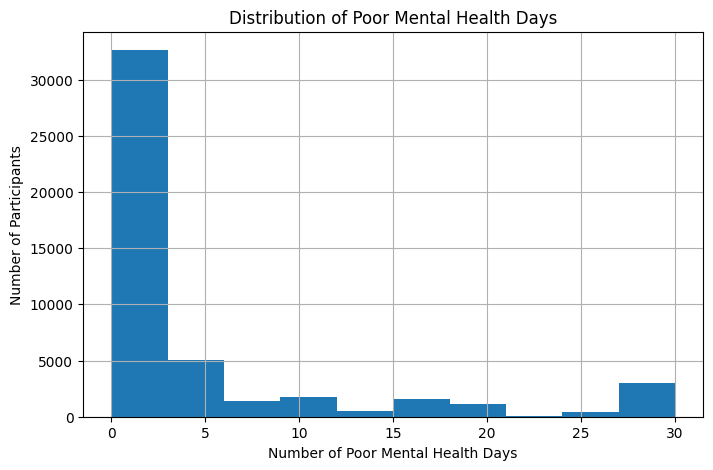

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
analysis_df['MENTHLTH_CLEAN'].hist()
plt.title('Distribution of Poor Mental Health Days')
plt.xlabel('Number of Poor Mental Health Days')
plt.ylabel('Number of Participants')
plt.show()

### Distribution of Mental Health Burden

The histogram shows that most participants report low or zero poor mental health days, while a smaller group experiences higher levels of mental health burden. This indicates a right-skewed distribution.

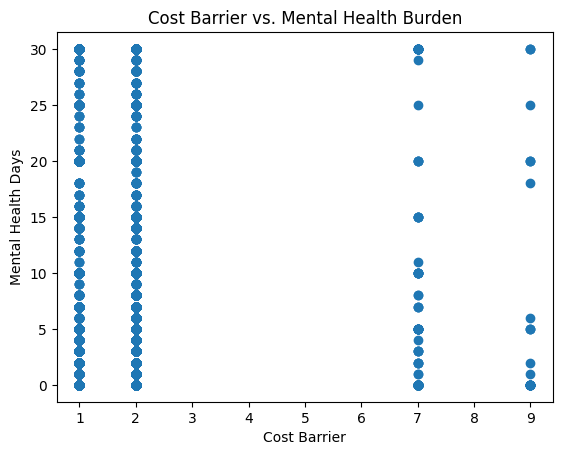

In [ ]:
# Scatter Plot (Relationship)
plt.figure()
plt.scatter(analysis_df['MEDCOST1'], analysis_df['MENTHLTH_CLEAN'])
plt.xlabel('Cost Barrier')
plt.ylabel('Mental Health Days')
plt.title('Cost Barrier vs. Mental Health Burden')
plt.show()


### Relationship Between Cost Barriers and Mental Health

The scatter plot shows that individuals with cost barriers tend to have higher mental health burden. While the relationship is not perfectly linear, there is a visible pattern where higher values are more frequent among those facing cost barriers.

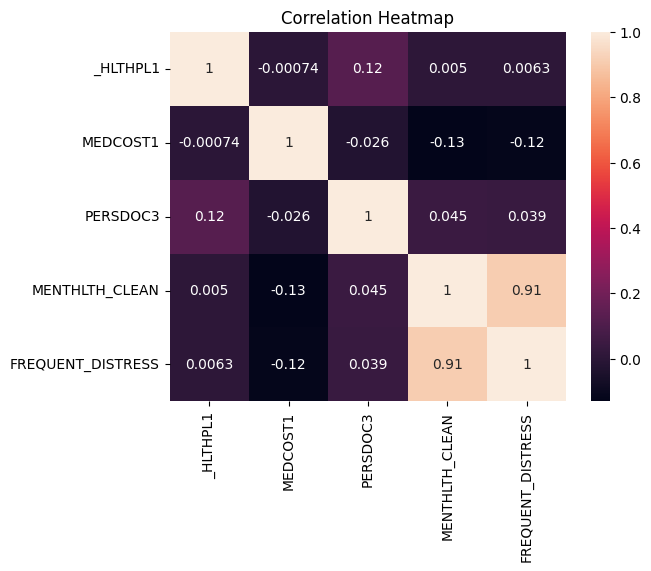

In [ ]:
# Heatmap (Correlation Visualization)
import seaborn as sns

plt.figure()
sns.heatmap(analysis_df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

### Correlation Heatmap

The heatmap shows generally weak correlations between healthcare access variables and mental health burden. The strongest relationship observed is between `MENTHLTH_CLEAN` and `FREQUENT_DISTRESS` (0.92), which is expected since both variables measure mental health outcomes.

Healthcare access variables such as cost barriers, insurance coverage, and access to a personal doctor show weak correlations with mental health burden. This suggests that correlation alone does not fully capture the relationships between these variables.

However, earlier group comparison analysis revealed meaningful differences, particularly for cost barriers, indicating that distribution-based methods provide more insight than correlation in this case.

In [ ]:
analysis_df['COST_BARRIER_LABEL'] = analysis_df['MEDCOST1'].map({
    1: 'Cost Barrier',
    2: 'No Cost Barrier',
    7: "Don't Know",
    9: 'Refused'
})

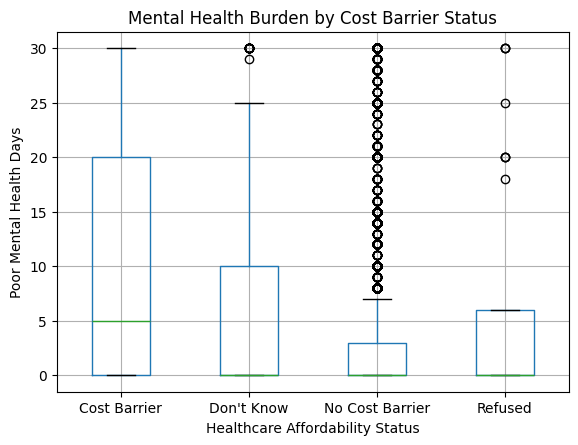

In [ ]:
# Boxplot
analysis_df.boxplot(column='MENTHLTH_CLEAN', by='COST_BARRIER_LABEL')
plt.title('Mental Health Burden by Cost Barrier Status')
plt.suptitle('')
plt.xlabel('Healthcare Affordability Status')
plt.ylabel('Poor Mental Health Days')
plt.show()

### Mental Health by Cost Barrier

The boxplot shows that participants facing cost barriers have a higher median and a wider distribution of poor mental health days compared to those without cost barriers.

Most individuals without cost barriers report low or zero poor mental health days, while those with cost barriers show both higher typical values and more extreme cases.

This indicates that affordability is strongly associated with increased mental health burden.

### Time-Based Analysis

The dataset does not include time-based variables, so time-series analysis was not performed. However, this technique would be valuable in future analyses to track changes in mental health outcomes over time.

## Final Exploratory Data Analysis Summary

The exploratory data analysis provided valuable insights into the distribution and relationships between healthcare access factors and mental health burden.

The distribution of mental health days is highly right-skewed, with most participants reporting zero or very few poor mental health days, while a smaller group experiences significantly higher values. This indicates that mental health burden is not evenly distributed across the population.

Correlation analysis showed generally weak relationships between healthcare access variables and mental health outcomes. The strongest correlation was observed between `MENTHLTH_CLEAN` and `FREQUENT_DISTRESS` (0.92), which is expected since both variables measure similar aspects of mental health. However, variables such as cost barriers, insurance coverage, and access to a personal doctor showed weak linear relationships with mental health burden.

Despite weak correlations, group comparison analysis and visualizations revealed more meaningful patterns. The boxplot and summary statistics showed that participants facing cost barriers had significantly higher mental health burden compared to those without cost barriers. Additionally, individuals without access to a personal doctor also reported higher levels of poor mental health days.

These findings suggest that while healthcare access variables may not strongly predict mental health outcomes in a linear model, they are associated with noticeable differences across groups. This highlights the importance of using multiple analytical approaches, including distribution analysis and group comparisons, to fully understand complex real-world data.

Overall, the EDA supports the conclusion that affordability and access to care are important factors associated with mental health burden, particularly within the Alameda County subset.